In [1]:
import pandas as pd

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv('../data/transactions.csv')

In [4]:

df.info()
df['is_fraud'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             12000 non-null  int64  
 1   transaction_amount         12000 non-null  float64
 2   hour_of_day                12000 non-null  int64  
 3   customer_age_days          12000 non-null  float64
 4   num_transactions_last_24h  12000 non-null  int64  
 5   distance_from_home_km      12000 non-null  float64
 6   merchant_category          12000 non-null  object 
 7   is_foreign_transaction     12000 non-null  int64  
 8   is_fraud                   12000 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 843.9+ KB


is_fraud
0    11821
1      179
Name: count, dtype: int64

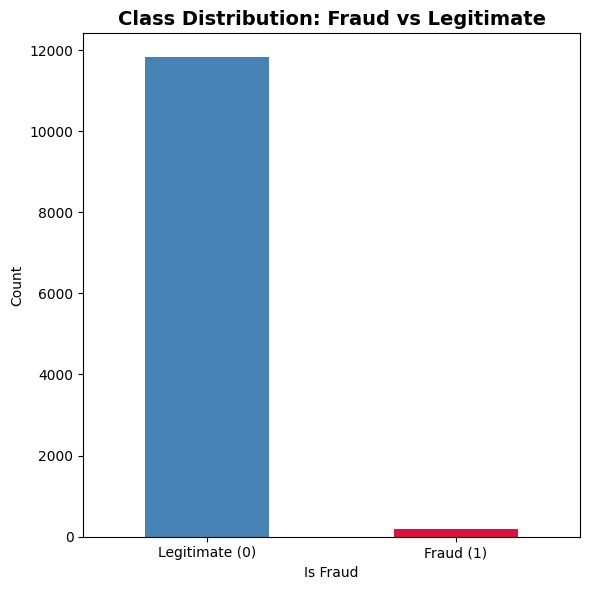

In [5]:

plt.figure(figsize=(6, 6))
df['is_fraud'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Class Distribution: Fraud vs Legitimate', fontsize=14, fontweight='bold')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [6]:
df_encoded = pd.get_dummies(df, columns=['merchant_category'], drop_first=True)

X = df_encoded.drop(['transaction_id', 'is_fraud'], axis=1)
y = df_encoded['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# Result: Accuracy = 0.99 (looks great) but Recall for fraud = 0.11


[[2363    1]
 [  32    4]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2364
           1       0.80      0.11      0.20        36

    accuracy                           0.99      2400
   macro avg       0.89      0.56      0.59      2400
weighted avg       0.98      0.99      0.98      2400



Address imbalance - class_weight='balanced

In [8]:
model_balanced = LogisticRegression(max_iter=3000, class_weight='balanced')
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))
# Result: Recall improved dramatically to 0.67, but Precision dropped to
# 0.05 (426 false positives). This confirms the precision/recall trade-off:
# telling the model to weigh minority-class errors more heavily catches
# more fraud, at the cost of many false alarms on legitimate transactions

[[1938  426]
 [  12   24]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      2364
           1       0.05      0.67      0.10        36

    accuracy                           0.82      2400
   macro avg       0.52      0.74      0.50      2400
weighted avg       0.98      0.82      0.89      2400



 - Random Forest

In [9]:
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Result: WORSE - Recall dropped to 0.00, missing all 36 fraud cases.
# class_weight='balanced' does not translate to the same effect in Random


[[2363    1]
 [  36    0]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2364
           1       0.00      0.00      0.00        36

    accuracy                           0.98      2400
   macro avg       0.49      0.50      0.50      2400
weighted avg       0.97      0.98      0.98      2400



  Threshold tuning on the balanced Logistic Regression model

In [10]:
y_proba = model_balanced.predict_proba(X_test)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold={t:.1f} | Precision={p:.2f} | Recall={r:.2f} | F1={f1:.2f}")

Threshold=0.2 | Precision=0.02 | Recall=0.97 | F1=0.05
Threshold=0.3 | Precision=0.03 | Recall=0.92 | F1=0.07
Threshold=0.4 | Precision=0.04 | Recall=0.72 | F1=0.07
Threshold=0.5 | Precision=0.05 | Recall=0.67 | F1=0.10
Threshold=0.6 | Precision=0.08 | Recall=0.61 | F1=0.13
Threshold=0.7 | Precision=0.10 | Recall=0.50 | F1=0.17


Business justification: for a payments company, missing real fraud
 (false negatives) is costlier than flagging legitimate transactions for
 review (false positives), so recall is prioritized. This model is a
 reasonable baseline, not a finished production system - next real-world
 steps would include richer features, SMOTE oversampling, and treating
 model output as a flag for human review rather than an automatic block